# Logistic Regression
Linear baseline: a weighted sum of the features squashed into a probability.

**Task:** given a satellite, the space weather and its anomaly history at the moment of an anomaly, predict whether the *next* anomaly happens within `HORIZON_DAYS` days (see `src/config.py`).

**Structure:** 1 Imports → 2 Datasets → 3 Preprocessing → 4 Define model → 5 Train → 6 Plots and results

## 1. Imports

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from src import config as C
from src.preprocessing.load_data import load_anomalies, load_satcat, load_sunspot
from src.preprocessing.clean_data import clean_anomalies, satellite_table, match_satcat
from src.preprocessing.create_tte import build_tte_table, add_label
from src.evaluation.cv import grouped_oof_proba, save_predictions
from src.evaluation.metrics import classification_metrics
from src.evaluation.plots import plot_roc, plot_confusion

## 2. Datasets → pandas

In [2]:
raw_anomalies = load_anomalies()   # NOAA anomaly database (.xls)
satcat        = load_satcat()      # Celestrak satellite catalog
sunspot       = load_sunspot()     # daily sunspot number

for name, d in [("anomalies", raw_anomalies), ("satcat", satcat), ("sunspot", sunspot)]:
    print(f"{name:10s} {d.shape}")
raw_anomalies[["BIRD", "ADATE", "ORBIT", "ALT"]].head()

anomalies  (5033, 21)
satcat     (70857, 17)
sunspot    (6940,)


,BIRD,ADATE,ORBIT,ALT
0,AFSATCOM,1990-09-11,G,35784
1,AFTAC/WE,1992-04-15,G,35784
2,AMPTE/CCE,1987-10-27,E,54810
3,@PN0101,1978-10-04,G,35784
4,@PN0102,1974-06-15,G,35784


## 3. Preprocessing

In [3]:
# 1) clean: one row per satellite-day, drop pre-1976 anomalies and shuttle missions
events = clean_anomalies(raw_anomalies, C.SUNSPOT_START, C.EXCLUDE_PREFIXES).drop_duplicates(["BIRD", "ADATE"])
# 2) per-satellite attributes (orbit, altitude) + satcat match
sats = match_satcat(satellite_table(events), satcat)
# 3) one row per gap between anomalies, with features known at the START of the gap
tte = build_tte_table(events, sats, sunspot, C.MIN_EVENTS, C.CENSOR_MODE, events.ADATE.max())
# 4) binary label: does the next anomaly happen within HORIZON_DAYS?
df = add_label(tte, C.HORIZON_DAYS)

FEATURES = [f for g in C.MODEL_FEATURE_GROUPS for f in C.FEATURE_GROUPS[g]]
print(f"{len(df)} samples | {df.sat.nunique()} satellites | {len(FEATURES)} features")
print(f"label = 1 ('next anomaly within {C.HORIZON_DAYS} days'): {df.label.mean():.1%} of samples")

2871 samples | 58 satellites | 14 features
label = 1 ('next anomaly within 7 days'): 48.9% of samples


## 4. Define model

In [4]:
def make_model():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(max_iter=1000))

MODEL_NAME = "Logistic Regression"
MODEL_SLUG = "lr"

## 5. Train

In [5]:
# Satellite-grouped 5-fold CV: every sample gets a prediction from a model that never saw its satellite.
oof_proba, fold = grouped_oof_proba(make_model, df, FEATURES, C.N_SPLITS)
print("done:", len(oof_proba), "out-of-fold predictions")

done: 2871 out-of-fold predictions


## 6. Plots and results
Accuracy, precision, recall and F1 use a 0.5 probability threshold; ROC AUC uses the raw probabilities.

,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.607,0.599,0.595,0.597,0.643


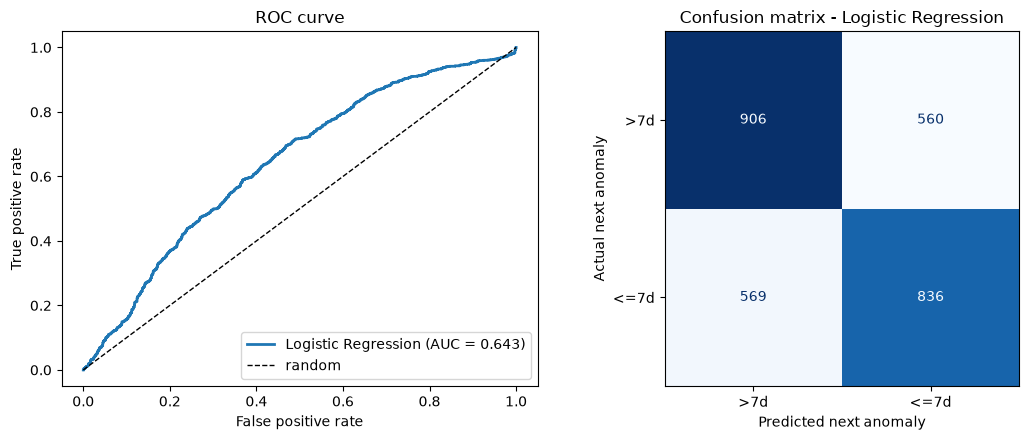

saved -> C:\Users\sowmy\OneDrive\Sowmya\College\SEM-5\ML\Satellite-Anomaly-Prediction-ML-Project\results\predictions_lr.csv


In [6]:
metrics = classification_metrics(df.label, oof_proba, C.THRESHOLD)
display(pd.DataFrame(metrics, index=[MODEL_NAME]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_roc(df.label, oof_proba, MODEL_NAME, ax=axes[0])
plot_confusion(df.label, oof_proba, MODEL_NAME, ax=axes[1])
plt.tight_layout(); plt.show()

print("saved ->", save_predictions(df, oof_proba, fold, MODEL_SLUG))